In [1]:
import pandas as pd

# Load dataset
file_path = "Downloads/Dataset .csv"
df = pd.read_csv(file_path)

# Display column names
print("Columns in Dataset:\n", df.columns)


Columns in Dataset:
 Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [2]:
# Convert categorical columns to lowercase for consistency
df["Has Table booking"] = df["Has Table booking"].str.lower()
df["Has Online delivery"] = df["Has Online delivery"].str.lower()

# Calculate percentages
table_booking_percentage = (df["Has Table booking"].value_counts(normalize=True) * 100)
online_delivery_percentage = (df["Has Online delivery"].value_counts(normalize=True) * 100)

print("\nPercentage of Restaurants Offering Table Booking:\n", table_booking_percentage)
print("\nPercentage of Restaurants Offering Online Delivery:\n", online_delivery_percentage)


Percentage of Restaurants Offering Table Booking:
 Has Table booking
no     87.875615
yes    12.124385
Name: proportion, dtype: float64

Percentage of Restaurants Offering Online Delivery:
 Has Online delivery
no     74.337766
yes    25.662234
Name: proportion, dtype: float64


C:\Users\Aditi\AppData\Local\Temp\ipykernel_8584\2824434246.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=table_booking_ratings.index, y=table_booking_ratings.values, palette="coolwarm")


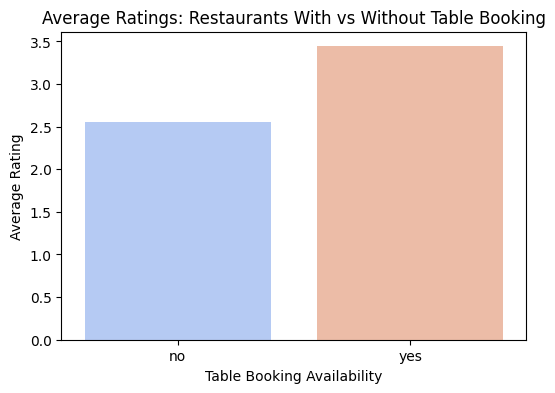

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute average ratings
table_booking_ratings = df.groupby("Has Table booking")["Aggregate rating"].mean()

# Plot bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=table_booking_ratings.index, y=table_booking_ratings.values, palette="coolwarm")
plt.xlabel("Table Booking Availability")
plt.ylabel("Average Rating")
plt.title("Average Ratings: Restaurants With vs Without Table Booking")
plt.show()

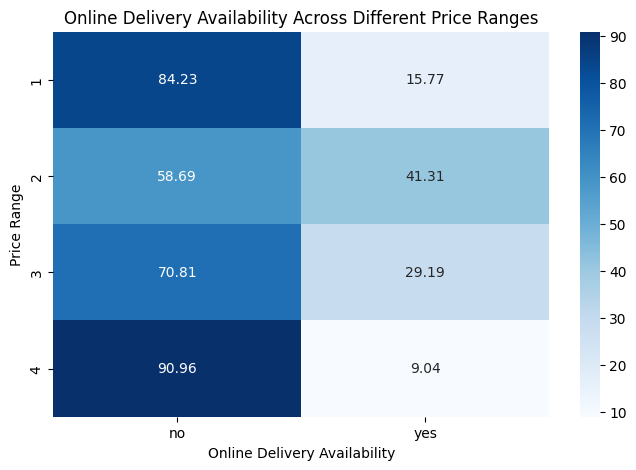

In [4]:
# Convert Price range to a categorical variable if not already
df["Price range"] = df["Price range"].astype(str)

# Compute percentage of restaurants with online delivery in each price range
delivery_price_range = df.groupby("Price range")["Has Online delivery"].value_counts(normalize=True).unstack() * 100

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(delivery_price_range, annot=True, cmap="Blues", fmt=".2f")
plt.xlabel("Online Delivery Availability")
plt.ylabel("Price Range")
plt.title("Online Delivery Availability Across Different Price Ranges")
plt.show()